<a href="https://colab.research.google.com/github/JoaoCarv05/Lab-07/blob/main/esza019_2026_2__lab7__cnn_intro_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESZA019 - Visão Computacional
## Laboratório 7 - Introdução às redes CNN
*Convolutional Neural Networks* para Reconhecimento em Imagens

---

**Autores:**
 - João Victor de Castro Carvalho — RA 11202420287
 - Mario Guerreiro Cerconvis — RA 11202421459
 - Marco Antonio Silva da Mata — RA 11202320279
 - João Victor Gonçalves Nascimento — RA 11202420821

**Data de realização dos experimentos:** 03/08/2026

**Data de publicação do relatório:** 03/08/2026

---

Neste roteiro, para fins didáticos, utilizaremos o **Google Colab Interativo** o framework  **TensorFlow / Keras**, projetado para alunos de graduação em Engenharia e Computação.

Fundamentos: **Szeliski, R. *Computer Vision: Algorithms and Applications (2nd Ed.)*, Capítulo 5.4.**

Aplicação prática em robótica móvel/manipulação: integração de visão em tempo real usando a webcam.

O relatório da equipe deverá ser feito no **Jupyter notebook**.

---

## 🎯 Objetivos de Aprendizagem
1. Compreender a transição dos **Filtros Espaciais Clássicos** (Sobel, Gaussiano) para os **Filtros Aprendidos (CNN)**.
2. Construir e treinar uma CNN compacta em **TensorFlow/Keras** para reconhecimento de objetos.
3. Inspecionar os *Feature Maps* das camadas convolucionais para "abrir a caixa-preta" da rede.
4. Testar a rede em tempo real conectando um sensor de visão (Webcam) diretamente no Colab.

---

## 📚 Conexão Teórica: Szeliski Cap. 5.4
No processamento de imagem tradicional, definimos manualmente os pesos do filtro. Por exemplo, para detectar bordas verticais para navegação de um robô, usamos um filtro Sobel $3 \times 3$:

$$H = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

Como visto em **Szeliski 5.4**, uma **Camada Convolucional** aplica múltiplos kernels $K \times K \times C$ em paralelo, mas com uma diferença fundamental: **os valores do kernel são parâmetros ajustáveis $(\theta)$ aprendidos via Gradiente Descendente e Backpropagation**.


In [1]:
## IMPORTANTE: Antes de iniciar, configure no menu do Colab:
# [Edit] -> [Notebook settings] -> ()T4 GPU

In [2]:
## 1. Importação de Bibliotecas
# Importação das bibliotecas essenciais
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"Versão do TensorFlow: {tf.__version__}")
# Verificar se a GPU está ativa (fundamental para aceleração em robótica)
gpu_available = len(tf.config.list_physical_devices('GPU')) > 0
print(f"Aceleração por GPU Ativa: {gpu_available}")

Versão do TensorFlow: 2.20.0
Aceleração por GPU Ativa: True


In [20]:
from google.colab import drive
import os # Importar o módulo os para interagir com o sistema de arquivos

# Montar o Google Drive
drive.mount('/content/drive')

print("Google Drive montado com sucesso! Agora você pode acessar seus arquivos em '/content/drive'.")

# Definir o caminho para a pasta específica no seu Google Drive
drive_folder_path = '/content/drive/MyDrive'

# Verificar se a pasta existe e listar seu conteúdo
if os.path.exists(drive_folder_path):
    print(f"Conteúdo da pasta '{drive_folder_path}':")
    print(os.listdir(drive_folder_path))
else:
    print(f"A pasta '{drive_folder_path}' não foi encontrada. Por favor, verifique se o nome da pasta está correto e se ela existe em 'Meu Drive'.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado com sucesso! Agora você pode acessar seus arquivos em '/content/drive'.
Conteúdo da pasta '/content/drive/MyDrive':
['Filosofia.mp4', 'Proteinas grupo 4 .mp4', 'Tijolo maciço comum, João victor, Marcio Morollo e Milena Alegre.mp4', 'video biooooo.mp4', 'milena.mp4', 'IMG-20220620-WA0015.jpg', 'Screenshot_20220831-194601_Gallery.jpg', 'Base de Imóveis.gsheet', 'Cópia de GPT For Sheets FREE .gdoc', 'Colab Notebooks', 'Cópia de resposta forms ablublublue.gsheet', 'Planilha sem título (8).gsheet', 'Gastos mensais.gsheet', 'relacoes_de_filmes.gsheet', 'dados.gsheet', 'Planilha sem título (7).gsheet', 'customer_satisfaction_sample.csv', 'Planilha sem título (6).gsheet', 'Planilha sem título (5).gsheet', 'Planilha sem título (4).gsheet', 'Planilha sem título (3).gsheet', 'Planilha sem título (2).gsheet', 'Planilha sem título (1).gsh

In [21]:
import shutil
import os

source_path = '/content/drive/MyDrive/cifar-10-batches-py'
destination_path = './cifar-10-batches-py'

if os.path.exists(source_path):
    # Remover o diretório de destino se ele já existir para evitar erro ao copiar
    if os.path.exists(destination_path):
        print(f"Removendo diretório existente em {destination_path}...")
        shutil.rmtree(destination_path)

    print(f"Copiando '{source_path}' para '{destination_path}'...")
    shutil.copytree(source_path, destination_path)
    print("Cópia concluída com sucesso!")
    print(f"Conteúdo de '{destination_path}':")
    print(os.listdir(destination_path))
else:
    print(f"A pasta de origem '{source_path}' não foi encontrada no seu Google Drive. Por favor, verifique o caminho e se a pasta existe.")

Removendo diretório existente em ./cifar-10-batches-py...
Copiando '/content/drive/MyDrive/cifar-10-batches-py' para './cifar-10-batches-py'...
Cópia concluída com sucesso!
Conteúdo de './cifar-10-batches-py':
['data_batch_1', 'batches.meta', 'data_batch_3', 'data_batch_4', 'test_batch', 'data_batch_5', 'readme.html', 'data_batch_2']


## Parte 1. Filtro Manual (Sobel) vs. Conceito de Kernel Aprendido
Antes de construir a rede **CNN**, aplicar um **filtro de convolução** manual em uma imagem de teste para visualizar a **extração de características**.


Loading CIFAR-10 raw data from cache...


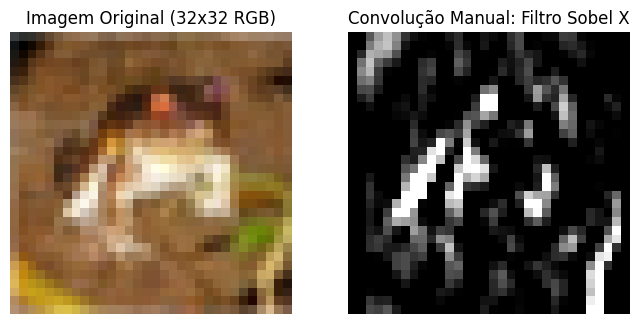

In [22]:
## 2. Convolução Clássica com OpenCV/NumPy
import os
import pickle # Adicionado para carregar o CIFAR-10 localmente
import numpy as np # Importado explicitamente para esta célula
import cv2 # Importado explicitamente para esta célula
import matplotlib.pyplot as plt # Importado explicitamente para esta célula

# Define paths for cached data
DATA_CACHE_DIR = './cifar10_cache'
TRAIN_IMAGES_PATH = os.path.join(DATA_CACHE_DIR, 'x_train_raw.npy')
TRAIN_LABELS_PATH = os.path.join(DATA_CACHE_DIR, 'y_train_raw.npy')

# Directory where the CIFAR-10 batch files are located
CIFAR10_LOCAL_DIR = './cifar-10-batches-py' # Novo caminho para os dados locais

# Create cache directory if it doesn't exist
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

# Helper function to unpickle CIFAR-10 batch files
def _unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Function to load CIFAR-10 training data from local files
def _load_cifar10_local_train_data(path):
    train_data = []
    train_labels = []
    for i in range(1, 6): # data_batch_1 through data_batch_5
        batch_path = os.path.join(path, f'data_batch_{i}')
        if not os.path.exists(batch_path):
            raise FileNotFoundError(f"CIFAR-10 batch file not found: {batch_path}")
        batch = _unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.append(batch[b'labels'])

    x_train = np.concatenate(train_data).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.concatenate(train_labels)
    return x_train, y_train.reshape(-1, 1) # Reshape labels to match Keras format (N, 1)

# Check if data is already cached
if os.path.exists(TRAIN_IMAGES_PATH) and os.path.exists(TRAIN_LABELS_PATH):
    print("Loading CIFAR-10 raw data from cache...")
    x_train_raw = np.load(TRAIN_IMAGES_PATH)
    y_train_raw = np.load(TRAIN_LABELS_PATH)
    # Assuming test data is not needed for this specific cell's purpose
    _ = np.array([]) # Placeholder for y_test_raw
else:
    # Check if local CIFAR-10 directory and batch files exist
    if os.path.exists(os.path.join(CIFAR10_LOCAL_DIR, 'data_batch_1')):
        print(f"Loading CIFAR-10 raw data from local directory: {CIFAR10_LOCAL_DIR}...")
        x_train_raw, y_train_raw = _load_cifar10_local_train_data(CIFAR10_LOCAL_DIR)
        # Cache the loaded data for future runs
        np.save(TRAIN_IMAGES_PATH, x_train_raw)
        np.save(TRAIN_LABELS_PATH, y_train_raw)
        _ = np.array([]) # Placeholder for y_test_raw
    else:
        raise FileNotFoundError(f"CIFAR-10 local data not found in {CIFAR10_LOCAL_DIR}. Please ensure the 'cifar-10-batches-py' folder with batch files is present or adjust the path.")

sample_img = x_train_raw[0] # Imagem 32x32 RGB

# Converter para escala de cinza
gray_img = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)

# Definindo o Filtro Sobel X (Bordas Verticais - Szeliski 5.4.1)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

# Aplicando a Convolução
edges_x = cv2.filter2D(gray_img, -1, sobel_x)

# Visualização
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Imagem Original (32x32 RGB)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_x, cmap='gray')
plt.title("Convolução Manual: Filtro Sobel X")
plt.axis('off')
plt.show()

**Elabore:** Numa nova célula abaixo, código para gerar mais exemplos desta filtragem, sendo pelo menos três imagens diferentes do dataset CIFAR-10, por aluno da equipe. Dica: modifique o índice no comando: sample_img = x_train_raw[0]


--- Exemplos para Aluno 1 ---


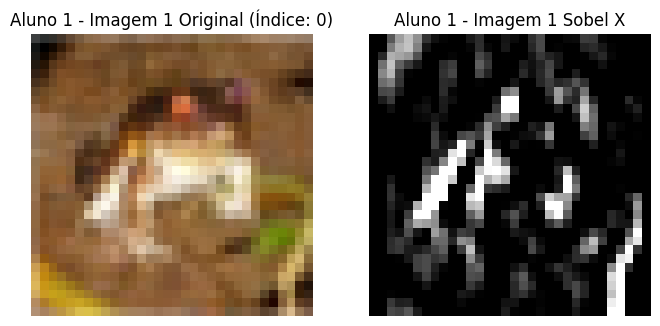

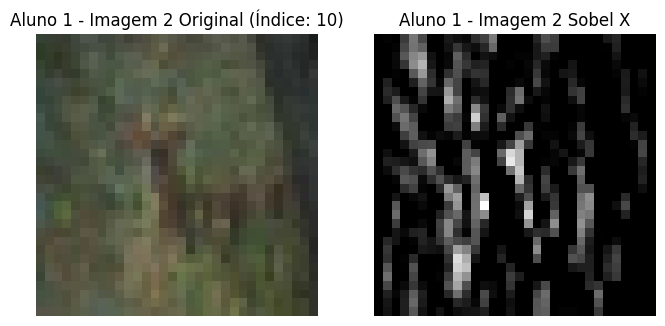

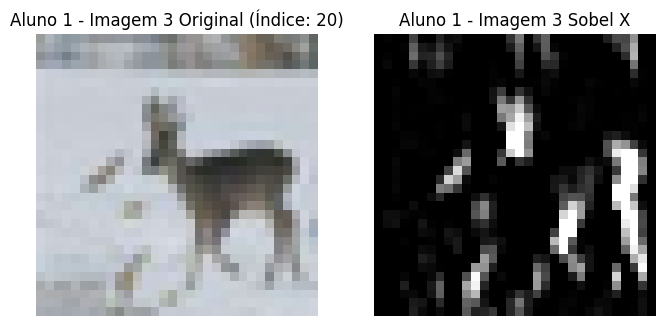


--- Exemplos para Aluno 2 ---


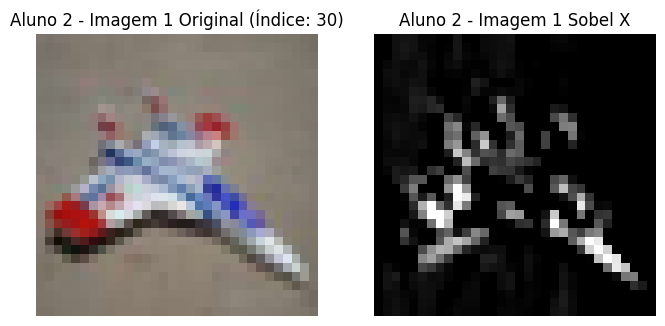

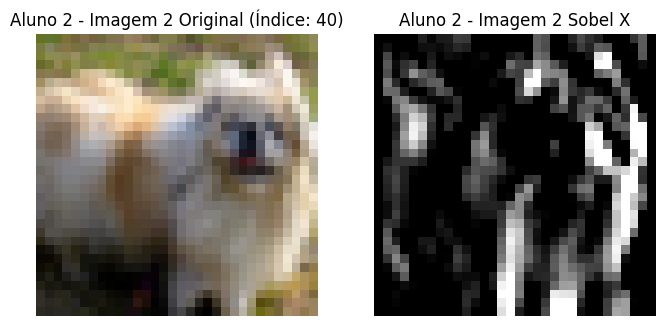

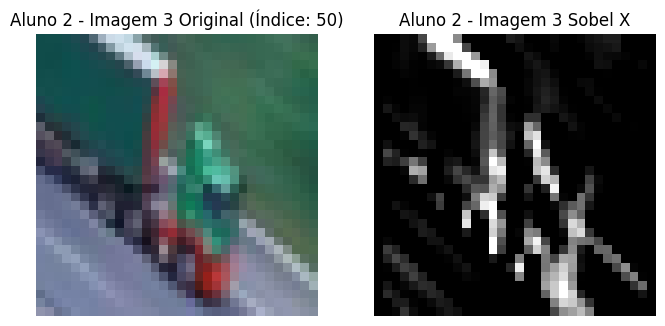


--- Exemplos para Aluno 3 ---


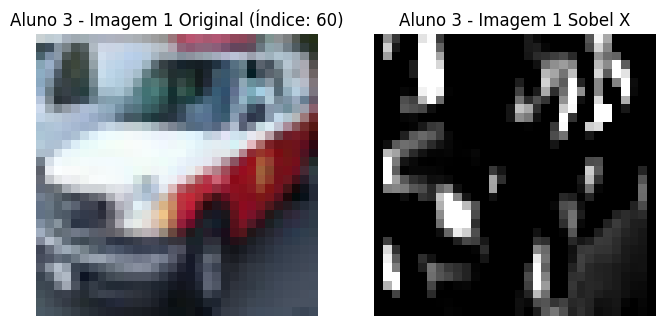

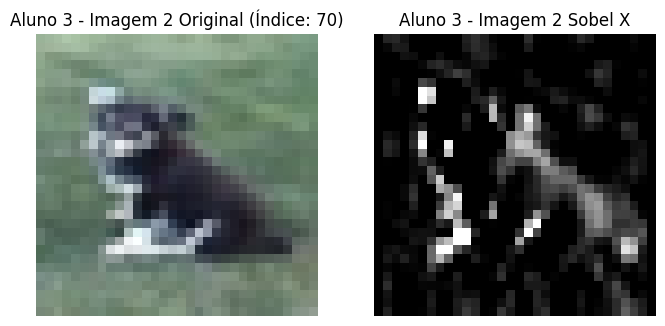

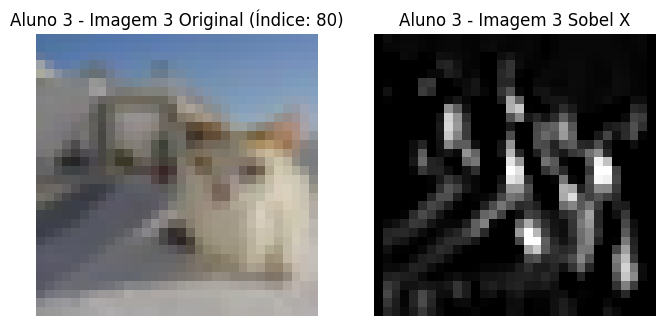


--- Exemplos para Aluno 4 ---


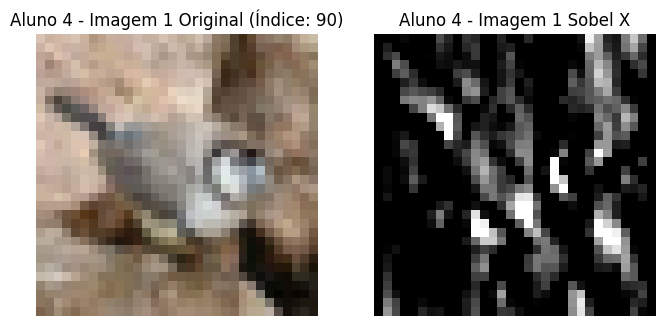

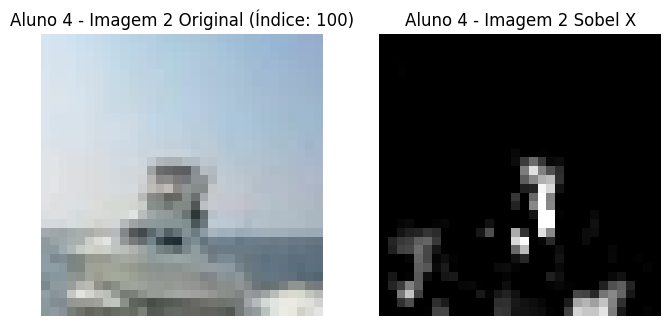

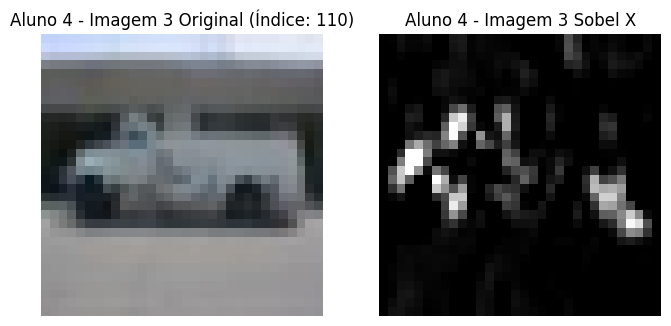

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

students = ['Aluno 1', 'Aluno 2', 'Aluno 3', 'Aluno 4']

image_indices = [
    [0, 10, 20],  # Aluno 1
    [30, 40, 50], # Aluno 2
    [60, 70, 80], # Aluno 3
    [90, 100, 110] # Aluno 4
]

for i, student_name in enumerate(students):
    print(f"\n--- Exemplos para {student_name} ---")
    for j, img_idx in enumerate(image_indices[i]):
        # Certifique-se de que x_train_raw está carregado
        sample_img = x_train_raw[img_idx]

        # Converter para escala de cinza
        gray_img = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)

        # Aplicando a Convolução
        edges_x = cv2.filter2D(gray_img, -1, sobel_x)

        # Visualização
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(sample_img)
        plt.title(f"{student_name} - Imagem {j+1} Original (Índice: {img_idx})")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(edges_x, cmap='gray')
        plt.title(f"{student_name} - Imagem {j+1} Sobel X")
        plt.axis('off')
        plt.show()


**Analise os resultados e responda com suas próprias palavras:** sobre a diferença entre processamento de imagem clássico e aprendizado profundo:

* **1:** Foi aplicado o filtro clássico de Sobel para detectar bordas verticais. Qual é a principal limitação matemática e prática de utilizar apenas filtros codificados manualmente (como Sobel ou Canny) no sistema de visão de um robô que navega em ambientes externos?

* **2:** Com base no capítulo 5.4 de Szeliski, explique com suas palavras: o que exatamente a rede neural está "aprendendo" durante a fase de treinamento em uma camada convolucional que substitui a necessidade de criarmos o filtro manualmente?

**1. Limitação dos filtros manuais (Sobel/Canny) para robôs em ambientes externos:**

A maior limitação desses filtros é que eles são fixos. O filtro Sobel sempre busca a mesma 'borda vertical perfeita'. Em um ambiente externo real, com luz mudando, sombra, objetos parciais ou ruídos, essas 'bordas perfeitas' quase nunca existem. O filtro manual não consegue aprender ou se ajustar a essas variações, o que levaria o robô a cometer muitos erros ou a perder informações importantes para navegar com segurança.

**2. O que a rede neural aprende em uma camada convolucional:**

Em vez de nós criarmos o filtro manualmente (como o Sobel), a rede neural aprende a criar seus próprios filtros durante o treinamento. Ela começa com filtros 'aleatórios' e, através do processo de aprendizado, ela ajusta os pesos desses filtros para que eles se tornem especialistas em detectar características importantes para a tarefa.



## Parte 2: Pipeline de Dados de Percepção

### . Preparação do Dataset (CIFAR-10)
Utilizaremos o dataset CIFAR-10 contendo 10 classes (incluindo veículos como *carro*, *caminhão*, *avião* e *navio*, relevantes para robótica móvel).

Loading CIFAR-10 raw data from local directory: ./cifar-10-batches-py...


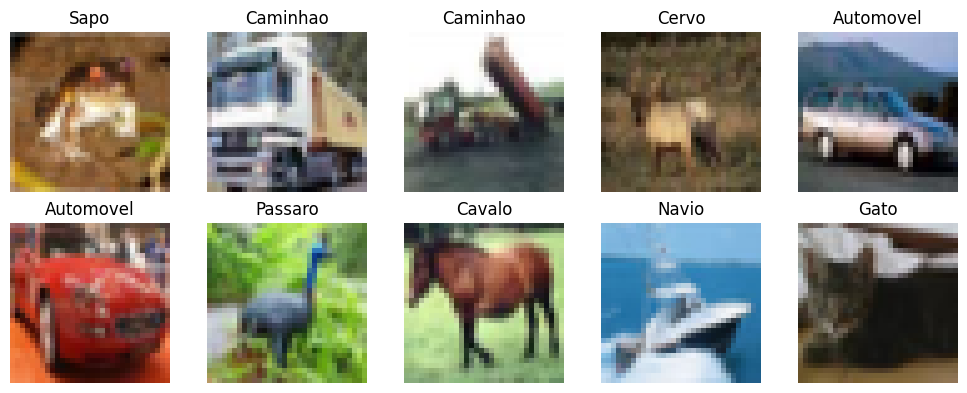

In [24]:
## 3. Download e Pré-processamento
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Define paths for cached data
DATA_CACHE_DIR = './cifar10_cache'
TRAIN_IMAGES_PATH = os.path.join(DATA_CACHE_DIR, 'x_train_raw.npy')
TRAIN_LABELS_PATH = os.path.join(DATA_CACHE_DIR, 'y_train_raw.npy')
TEST_IMAGES_PATH = os.path.join(DATA_CACHE_DIR, 'x_test_raw.npy')
TEST_LABELS_PATH = os.path.join(DATA_CACHE_DIR, 'y_test_raw.npy')

# Directory where the CIFAR-10 batch files are located
CIFAR10_LOCAL_DIR = './cifar-10-batches-py'

# Create cache directory if it doesn't exist
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

# Helper function to unpickle CIFAR-10 batch files
def _unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Function to load CIFAR-10 training data from local files
def _load_cifar10_local_train_data(path):
    train_data = []
    train_labels = []
    for i in range(1, 6): # data_batch_1 through data_batch_5
        batch_path = os.path.join(path, f'data_batch_{i}')
        if not os.path.exists(batch_path):
            raise FileNotFoundError(f"CIFAR-10 training batch file not found: {batch_path}")
        batch = _unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.append(batch[b'labels'])

    x_train = np.concatenate(train_data).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.concatenate(train_labels)
    return x_train, y_train.reshape(-1, 1) # Reshape labels to (N, 1)

# Function to load CIFAR-10 test data from local files
def _load_cifar10_local_test_data(path):
    test_batch_path = os.path.join(path, 'test_batch')
    if not os.path.exists(test_batch_path):
        raise FileNotFoundError(f"CIFAR-10 test batch file not found: {test_batch_path}")
    batch = _unpickle(test_batch_path)
    x_test = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(batch[b'labels'])
    return x_test, y_test.reshape(-1, 1) # Reshape labels to (N, 1)

# Check if data is already cached
if (os.path.exists(TRAIN_IMAGES_PATH) and os.path.exists(TRAIN_LABELS_PATH) and
    os.path.exists(TEST_IMAGES_PATH) and os.path.exists(TEST_LABELS_PATH)):
    print("Loading CIFAR-10 raw data from cache...")
    x_train = np.load(TRAIN_IMAGES_PATH)
    y_train = np.load(TRAIN_LABELS_PATH)
    x_test = np.load(TEST_IMAGES_PATH)
    y_test = np.load(TEST_LABELS_PATH)
else:
    # Check if local CIFAR-10 directory and batch files exist
    if os.path.exists(os.path.join(CIFAR10_LOCAL_DIR, 'data_batch_1')) and \
       os.path.exists(os.path.join(CIFAR10_LOCAL_DIR, 'test_batch')):
        print(f"Loading CIFAR-10 raw data from local directory: {CIFAR10_LOCAL_DIR}...")
        x_train, y_train = _load_cifar10_local_train_data(CIFAR10_LOCAL_DIR)
        x_test, y_test = _load_cifar10_local_test_data(CIFAR10_LOCAL_DIR)
        # Cache the loaded data for future runs
        np.save(TRAIN_IMAGES_PATH, x_train)
        np.save(TRAIN_LABELS_PATH, y_train)
        np.save(TEST_IMAGES_PATH, x_test)
        np.save(TEST_LABELS_PATH, y_test)
    else:
        raise FileNotFoundError(f"CIFAR-10 local data not found in {CIFAR10_LOCAL_DIR}. Please ensure the 'cifar-10-batches-py' folder with batch files is present or adjust the path. Alternatively, if local data is not available, you might consider re-enabling `tf.keras.datasets.cifar10.load_data()`.")

# Normalização dos píxeis para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['Aviao', 'Automovel', 'Passaro', 'Gato', 'Cervo',
               'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhao']

# Visualizar amostras
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre  a preparação dos dados sensoriais e representação matricial:

* **3:** Na preparação do dataset, os pixels foram divididos por $255.0$. Quanto à otimização matemática (cálculo de gradientes), por que essa normalização é necessária para o treinamento da rede neural do robô?

* **4:** O dataset CIFAR-10 possui apenas imagens de ($32 \times 32$ pixels). Se o robô utilizar câmera 4K ($3840 \times 2160$ pixels), o que aconteceria com a quantidade de parâmetros da primeira camada densa (*Flatten* seguida de *Dense*) e como isso impactaria o hardware embarcado? (Apresente exemplos)

3. A divisão dos valores dos pixels por 255,0, normalizando-os para o intervalo [0,1], melhora o treinamento das redes neurais ao evitar problemas de explosão ou desaparecimento dos gradientes durante o backpropagation. Além disso, acelera a convergência dos algoritmos de otimização, como SGD e Adam, e mantém as entradas das funções de ativação em uma faixa adequada, reduzindo a saturação e preservando a capacidade de aprendizado da rede.

4. Utilizar imagens 4K (3840×2160 pixels RGB) em uma camada Flatten seguida de uma Dense gera um número extremamente elevado de parâmetros. Uma imagem possui aproximadamente 24,8 milhões de características e, conectada a uma camada com 128 neurônios, resultaria em cerca de 3,18 bilhões de pesos. Esse volume de parâmetros exige grande capacidade de memória e processamento, inviabilizando a execução em hardware embarcado, aumenta significativamente a latência da inferência e torna o modelo mais suscetível ao overfitting.

## Parte 3: Construção da CNN em Keras

### . Arquitetura da Rede Convolucional (RobotVisionNet)
A arquitetura segue o padrão clássico descrito por Szeliski:
1. **Camadas Convolucionais (`Conv2D`):** Extração de mapas de características.
2. **Camadas de Max Pooling (`MaxPooling2D`):** Redução dimensional e garantia de **invariância a pequenas translações** do objeto no campo de visão da câmera.
3. **Camadas Densas (`Dense`):** Tomada de decisão/classificação final.


In [25]:
## 4. Definição do Modelo Keras

def build_robot_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        # Bloco Convolucional 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape, name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Bloco Convolucional 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Classificador (Fully Connected)
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_robot_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

**Analise os resultados e responda com suas próprias palavras:** sobre a arquitetura da rede e suas propriedades espaciais.

* **5:** Na arquitetura construída, por que as camadas convolucionais (Conv2D) são posicionadas no início do modelo e as camadas densas (Dense) apenas no final, e não o contrário? Qual o papel funcional de cada um desses blocos metodológicos?

5. As camadas Conv2D (convolucionais) são colocadas no início da rede porque sua função é extrair características hierárquicas da imagem. Elas detectam padrões locais de baixa a média complexidade (bordas, texturas, formas básicas) de forma eficiente, aproveitando a invariância translacional e reduzindo progressivamente a dimensionalidade espacial dos dados. Seu papel é atuar como 'detectores de features'.

As camadas Dense (totalmente conectadas) são posicionadas no final do modelo após as características terem sido extraídas e compactadas. Seu papel é realizar a classificação ou regressão final, utilizando as representações de alto nível e semanticamente ricas geradas pelas camadas convolucionais. Inverter essa ordem seria ineficiente e inviável para imagens, pois as camadas densas não conseguem processar efetivamente a grande quantidade de pixels brutos enquanto preservam a estrutura espacial, demandando um número proibitivo de parâmetros.

## Parte 4: Compilação e Treinamento

### . Treinamento da Rede
Definimos a função de perda (`sparse_categorical_crossentropy`) e o otimizador (`Adam`).


In [26]:
## 5. Execução do Treinamento

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento por 10 épocas
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test),
                    batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4229 - loss: 1.5814 - val_accuracy: 0.5575 - val_loss: 1.2342
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5535 - loss: 1.2450 - val_accuracy: 0.6284 - val_loss: 1.0500
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6108 - loss: 1.0962 - val_accuracy: 0.6622 - val_loss: 0.9612
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6485 - loss: 0.9996 - val_accuracy: 0.6745 - val_loss: 0.9167
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6727 - loss: 0.9304 - val_accuracy: 0.6876 - val_loss: 0.8884
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6906 - loss: 0.8702 - val_accuracy: 0.6984 - val_loss: 0.8570
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7093 - loss: 0.8215 - val_accuracy: 0.6962 - val_loss: 0.8621
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7219 - loss: 0.7804 - val_accuracy: 0

**Analise os resultados e responda com suas próprias palavras:** sobre a dinâmica do aprendizado, as métricas e a função de custo.

* **6:** Durante as 10 épocas de treinamento, o gráfico gerado mostra os valores da *Loss* (Perda). Defina o que a função de perda mede. Se o gráfico demonstrar que a perda de treinamento continua caindo rumo a zero, mas a perda de validação estaciona ou começa a subir, qual fenômeno está ocorrendo e como ele afetaria o robô na prática?


6. A função de perda quantifica o erro do modelo, medindo a diferença entre as previsões e os valores reais, guiando o treinamento para minimizá-la.

Quando a perda de treinamento continua caindo e a perda de validação estaciona ou sobe, ocorre sobreajuste. Isso significa que o modelo memorizou os dados de treinamento, incluindo ruídos, e perdeu a capacidade de generalizar para dados novos ou não vistos. Para um robô na prática, o overfitting é crítico, ele teria um desempenho excelente em condições idênticas às do treinamento, mas falharia em cenários reais com variações mínimas comprometendo sua segurança e autonomia.

## Parte 5: Diagnóstico e Matriz de Confusão

### . Avaliação do Desempenho
Em Engenharia Robótica, é necessário identificar falhas específicas: se o robô confundir um *automóvel* com um *caminhão*, o impacto na navegação pode ser tolerável; se confundir um *pedestre/animal* com um *objeto inanimado*, o erro é crítico.

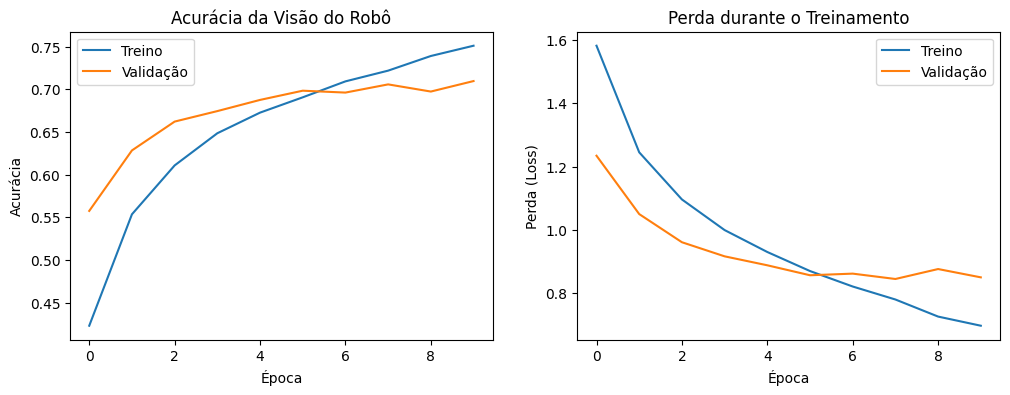

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


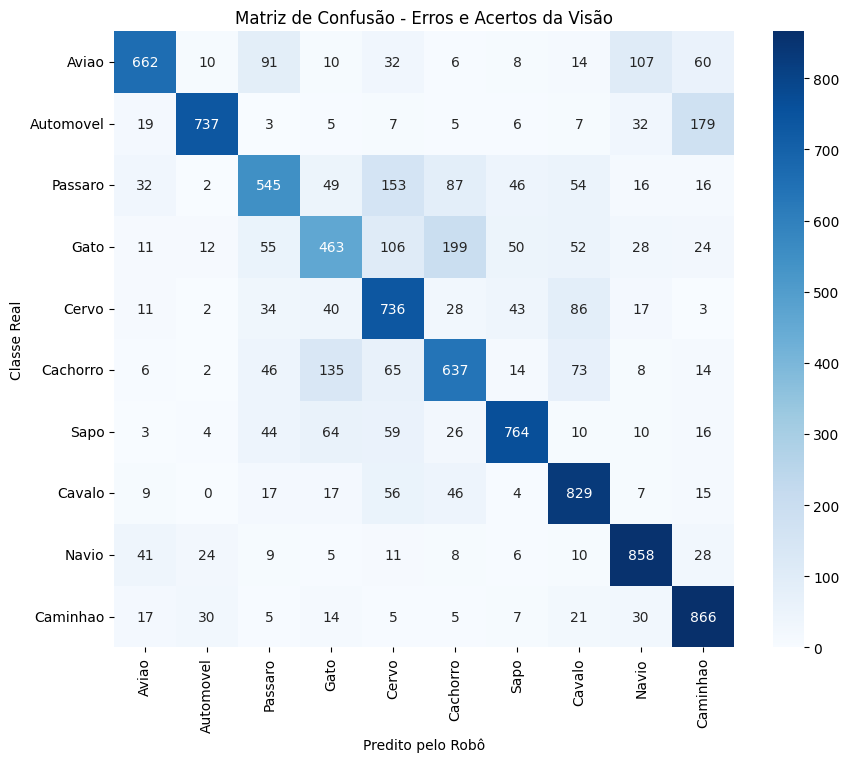

In [27]:
## 6. Gráficos e Matriz de Confusão

# Curvas de Aprendizado
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia da Visão do Robô')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Perda (Loss)')
plt.title('Perda durante o Treinamento')
plt.legend()
plt.show()

# Matriz de Confusão
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito pelo Robô')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Erros e Acertos da Visão')
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre as métricas de forma crítica com foco na tomada de decisão do robô.

* **7:** Observe a Matriz de Confusão gerada pelo seu modelo. Quais foram as duas classes com o maior índice de falsos positivos. Do ponto de vista da semântica das imagens, por que a rede cometeu esse erro específico?

* **8:** Se hipoteticamente este modelo é implantado no sistema de frenagem de emergência de um robô de patrulha. Errar a classe "Automóvel" classificando-a como "Caminhão" tem o mesmo peso de gravidade que classificar um "Cachorro" como um "Caminhão"? Como a matriz de confusão nos ajuda a auditar a segurança do robô?

7. Observando a matriz de confusão, as classes com maior índice de falsos positivos são Caminhão e Gato. A classe Caminhão recebeu muitas previsões incorretas de Automóvel, enquanto a classe Gato foi frequentemente confundida com Cachorro, Pássaro e outros animais. Esses erros acontecem porque algumas classes possuem características semelhantes. Automóveis e caminhões têm formatos parecidos, como rodas e carroceria, e costumam aparecer em ambientes semelhantes. Da mesma forma, gatos e cachorros compartilham características como pelagem e formato do corpo.

8. Classificar um automóvel como caminhão é um erro menos grave, pois o robô ainda identifica que existe um veículo e pode acionar a frenagem para evitar uma colisão. Já classificar um cachorro como caminhão é mais grave, pois o robô interpreta um animal como um veículo, podendo tomar decisões erradas. A matriz de confusão ajuda a identificar quais erros ocorrem com mais frequência, permitindo avaliar a segurança do modelo e indicar quais confusões precisam ser corrigidas antes de utilizá-lo em aplicações reais.

## Parte 6: Visualizando as Características Aprendidas (Szeliski 5.4.6)

### . Visualização dos *Feature Maps*
**Objetivo:** Extrair as saídas da primeira camada convolucional (`conv_1`) após o treinamento para comprovar que a rede aprendeu automaticamente detectores de bordas, orientação e contraste!

Atenção: os mapas de características (*feature_maps*) representam as ativações dos diferentes filtros (ou kernels) aprendidos pela primeira camada convolucional (conv_1) da rede. Estes elementos serão progressivamente combinados e refinados nas camadas mais profundas para formar representações complexas que permitirão à rede distinguir entre as dez classes diferentes do dataset CIFAR-10.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


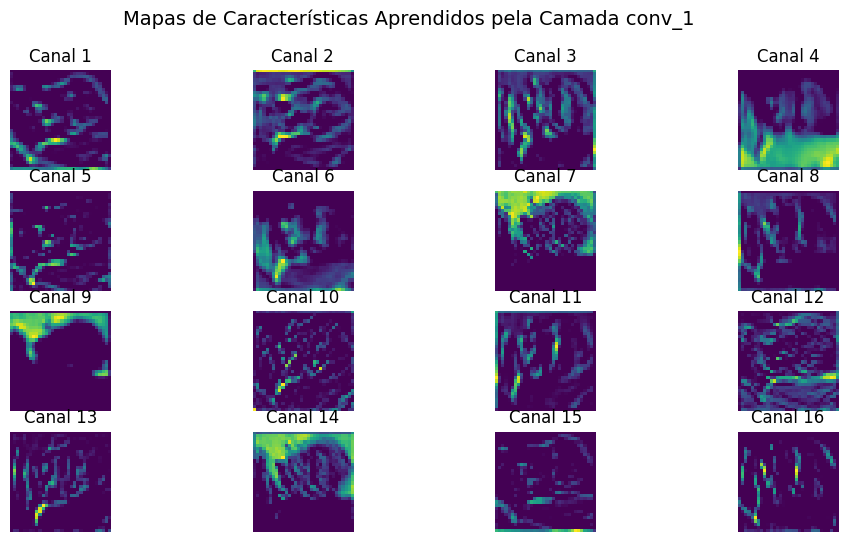

In [28]:
## 7. Inspeção de Ativações da Camada Convolucional

model.build(input_shape=(None, 32, 32, 3))
# Forçar o modelo a ser 'chamado' para garantir que seu grafo esteja construído
dummy_input = tf.zeros((1, 32, 32, 3))
_ = model(dummy_input)

# Criar modelo intermediário para extrair a saída da camada 'conv_1'
activation_model = tf.keras.Model(inputs=model.layers[0].input, outputs=model.get_layer('conv_1').output)

# Obter ativações para uma imagem de teste
sample_input = np.expand_dims(x_test[0], axis=0);
feature_maps = activation_model.predict(sample_input) # Formato: (1, 32, 32, 32)

plt.figure(figsize=(12, 6))
for i in range(16): # Exibir os primeiros 16 canais aprendidos
    plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Canal {i+1}')
plt.suptitle('Mapas de Características Aprendidos pela Camada conv_1', fontsize=14)
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre a interpretabilidade de redes neurais.

* **9:** Nas saídas (ativações) da camada conv_1, alguns canais destacam bordas enquanto outros destacam texturas. Caso visualizasse os *Feature Maps* da última camada convolucional antes do classificador, seria possível encontrar características mais simples (como linhas e pontos) ou mais complexas (como formatos abstratos do objeto inteiro)? Explique o motivo anatômico da CNN.

9: Em camadas como a última antes do classificador, você encontra características mais complexas, como formatos abstratos do objeto inteiro, em vez de características mais simples como linhas e pontos. A razão para isso é a ""anatomia" hierárquica das CNNs. As primeiras camadas aprendem a detectar características de baixo nível, como bordas e texturas. À medida que a informação passa por camadas convolucionais e de pooling subsequentes, a rede combina essas características de em representações cada vez mais complexas. Cada camada extrai características de um nível de abstração mais alto, construindo uma compreensão da imagem, até que as últimas camadas formam representações que são semanticamente ricas e discriminativas o suficiente para a tarefa de classificação final.


## Parte 7: Aplicação Prática com Webcam ao Vivo

### . Teste de Percepção em Tempo Real via Webcam
Agora conectar a câmera do seu computador! Mostrar objetos reais (como brinquedos de carros, miniaturas ou imagens no celular) para testar a predição da sua rede neural em tempo real.

Aguardando interação com a câmera...


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


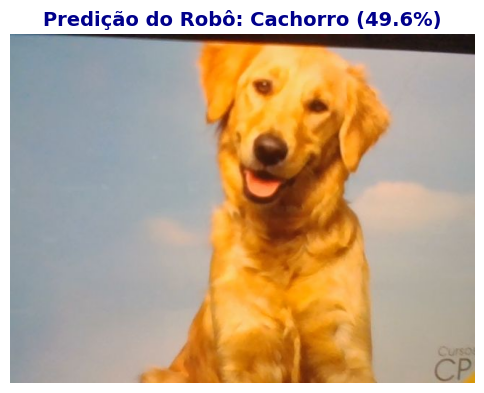

In [35]:
## 8. Bridge JavaScript/Python para Captura de Webcam no Colab

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import io
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função JavaScript para acessar a webcam e capturar um frame
def capture_webcam_frame():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const capture = document.createElement('button');

      capture.textContent = '📸 Capturar Frame e Classificar';
      capture.style.padding = '10px 20px';
      capture.style.fontSize = '16px';
      capture.style.backgroundColor = '#008CBA';
      capture.style.color = 'white';
      capture.style.border = 'none';
      capture.style.borderRadius = '5px';
      capture.style.cursor = 'pointer';
      capture.style.marginTop = '10px';

      video.style.display = 'block';
      video.style.borderRadius = '8px';

      let stream;
      try {
        stream = await navigator.mediaDevices.getUserMedia({video: true});
      } catch (err) {
        throw new Error("Permissão da câmera negada. Por favor, permita o acesso na barra do navegador.");
      }

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])
    img_pil = Image.open(io.BytesIO(binary))
    img_np = np.array(img_pil)
    return img_np

try:
    print("Aguardando interação com a câmera...")
    raw_frame = capture_webcam_frame()

    # Pré-processamento
    img_resized = cv2.resize(raw_frame, (32, 32))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = np.expand_dims(img_normalized, axis=0)

    # Inferência
    prediction = model.predict(img_tensor)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx] * 100

    # Exibição
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_frame)
    plt.title(f"Predição do Robô: {class_names[class_idx]} ({confidence:.1f}%)",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Erro ao acessar a câmera: {e}")

**Analise os resultados e responda com suas próprias palavras:**   robustez, latência e transferência do modelo para o mundo físico.

* **10:** O fenômeno de *Domain Shift* (mudança de domínio) ocorre quando os dados em que o modelo foi treinado diferem substancialmente dos dados em que ele é testado. Cite pelo menos três fatores físicos do ambiente da sua webcam que diferem das imagens originais do CIFAR-10 e que fizeram a acurácia do seu modelo cair ao vivo.

* **11:** Quando o código captura um frame da sua webcam e realiza a inferência (model.predict), isso consome um certo tempo em milissegundos. Se um robô móvel avança a $2 \text{ m/s}$ e o seu pipeline de visão da webcam demora $500 \text{ ms}$ para processar a imagem e classificar um obstáculo, quantos metros o robô terá percorrido "às cegas" entre o momento da captura e a decisão final? Comente a relação entre complexidade da CNN e segurança mecânica.

---

## 💡 Parte 8: QUESTÕES:

1. ** *Trade-off* (compromisso) entre Latência vs. Acurácia:**

Questão 1:
* *"Se o robô operar a 30 FPS, ele dispõe de apenas 33 ms por ciclo para capturar a imagem, processar a CNN e enviar o comando aos motores. Qual é o tempo de inferência da rede que acabamos de treinar?"*

Dica: (`time.time()` antes e depois do `model.predict`).


2. **A "Ilusão" da Acurácia em Ambiente Controlado:**

Questão 2:
*  Com a webcam, a acurácia poderá ser bem menor em relação ao conjunto de teste do CIFAR-10.
* Discuta os fatores: **iluminação ambiente**, **fundo complexo**, **mudança de escala**. Apresente exemplos com imagens de cada um destes fatores.


#### Questão 1:


In [36]:
import time
import numpy as np

# Usar uma única imagem de teste para calcular o tempo de inferência
sample_input = np.expand_dims(x_test[0], axis=0)

# Fazer uma predição inicial para 'aquecer' o modelo e evitar latência da primeira chamada
_ = model.predict(sample_input, verbose=0)

# Medir o tempo de inferência para 100 predições e tirar a média para uma medida mais robusta
num_inferences = 100
start_time = time.time()
for _ in range(num_inferences):
    _ = model.predict(sample_input, verbose=0)
end_time = time.time()

inference_time_ms = ((end_time - start_time) / num_inferences) * 1000

print(f"Tempo de inferência por imagem: {inference_time_ms:.3f} ms")


Tempo de inferência por imagem: 81.796 ms


#### Questão 2:

A acurácia do modelo pode diminuir bastante ao usar a webcam por causa da mudança de domínio (*domain shift*). Isso acontece porque a iluminação varia, o fundo é mais complexo e os objetos podem aparecer em diferentes tamanhos, distâncias e ângulos, diferente das imagens padronizadas do CIFAR-10. Essas diferenças dificultam o reconhecimento e reduzem o desempenho do modelo.


## Parte 9:  🚀 Desafio Prático

Adicionar uma célula ao final do notebook e implementarem as seguintes melhorias:

1. **Aumento de Dados (*Data Augmentation*):**
Adicionar camadas de transformação aleatória na entrada do modelo Keras para tornar o robô mais robusto a variações de orientação e iluminação na câmera:

In [37]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

2. **Filtro de Rejeição por Confiança (Safety Threshold):**
Modificar o código da webcam para que o robô emita um aviso de *"Objeto Não Identificado / Incerto"* caso a confiança da maior probabilidade seja inferior a **60%** ($\text{Confiança} < 0.60$), prevenindo ações desastrosas do manipulador mecânico.

## Parte 9: 🚀 Desafio Prático - Implementação das Melhorias

Conforme solicitado, as melhorias de Aumento de Dados e Filtro de Rejeição por Confiança serão implementadas em novas células abaixo.

### 9.1. Aumento de Dados (*Data Augmentation*)

Vamos adicionar camadas de transformação aleatória na entrada do modelo Keras para torná-lo mais robusto a variações de orientação e iluminação na câmera.

In [ ]:
# Define as camadas de data augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

print("Camadas de Aumento de Dados definidas.")

### 9.2. Atualização da Arquitetura do Modelo com Data Augmentation

Agora, integramos essas camadas de `data_augmentation` na função `build_robot_cnn` como a primeira camada do modelo. Isso significa que as imagens de entrada serão aleatoriamente transformadas *antes* de passarem pelas camadas convolucionais, o que ajuda o modelo a aprender recursos mais generalizáveis.

In [40]:
def build_robot_cnn_augmented(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        tf.keras.Input(shape=input_shape), # Define the explicit input shape for the model
        data_augmentation, # Aplica aumento de dados como a primeira camada
        # Bloco Convolucional 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Bloco Convolucional 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Classificador (Fully Connected)
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

# Re-instancie o modelo com a arquitetura atualizada
model = build_robot_cnn_augmented()
model.summary()
print("Modelo CNN atualizado com camadas de aumento de dados.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Modelo CNN atualizado com camadas de aumento de dados.


### 9.3. Recompilação e Re-treinamento do Modelo

Com a nova arquitetura do modelo (incluindo o aumento de dados), é essencial recompilar e re-treinar o modelo para que ele possa aprender com as imagens aumentadas. Isso pode levar mais tempo para treinar e pode resultar em diferentes métricas de desempenho.

In [41]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Iniciando re-treinamento do modelo com aumento de dados...")
# Treinamento por 10 épocas
history_augmented = model.fit(x_train, y_train,
                                 epochs=10,
                                 validation_data=(x_test, y_test),
                                 batch_size=64)
print("Re-treinamento concluído.")

Iniciando re-treinamento do modelo com aumento de dados...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3859 - loss: 1.6867 - val_accuracy: 0.4761 - val_loss: 1.4306
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4834 - loss: 1.4390 - val_accuracy: 0.5572 - val_loss: 1.2370
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5203 - loss: 1.3423 - val_accuracy: 0.5806 - val_loss: 1.1682
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5429 - loss: 1.2909 - val_accuracy: 0.6090 - val_loss: 1.0958
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5566 - loss: 1.2459 - val_accuracy: 0.6060 - val_loss: 1.1422
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5751 - loss: 1.2058 - val_accuracy: 0.6382 - val_loss: 1.0277
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5830 - loss: 1.1751 - val_accuracy: 0.6461 - val_loss: 1.0155
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━

### 9.4. Filtro de Rejeição por Confiança (Safety Threshold)

Agora, vamos modificar o código da webcam para que o robô emita um aviso de "Objeto Não Identificado / Incerto" caso a confiança da maior probabilidade seja inferior a 60%, prevenindo ações desastrosas.

Aguardando interação com a câmera para classificação com filtro de confiança...


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


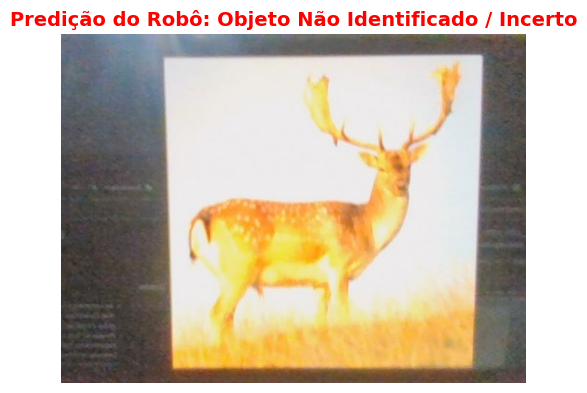

In [43]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import io
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função JavaScript para acessar a webcam e capturar um frame
def capture_webcam_frame_with_confidence():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const capture = document.createElement('button');

      capture.textContent = '📸 Capturar Frame e Classificar';
      capture.style.padding = '10px 20px';
      capture.style.fontSize = '16px';
      capture.style.backgroundColor = '#008CBA';
      capture.style.color = 'white';
      capture.style.border = 'none';
      capture.style.borderRadius = '5px';
      capture.style.cursor = 'pointer';
      capture.style.marginTop = '10px';

      video.style.display = 'block';
      video.style.borderRadius = '8px';

      let stream;
      try {
        stream = await navigator.mediaDevices.getUserMedia({video: true});
      } catch (err) {
        throw new Error("Permissão da câmera negada. Por favor, permita o acesso na barra do navegador.");
      }

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])
    img_pil = Image.open(io.BytesIO(binary))
    img_np = np.array(img_pil)
    return img_np

try:
    print("Aguardando interação com a câmera para classificação com filtro de confiança...")
    raw_frame = capture_webcam_frame_with_confidence()

    # Pré-processamento
    img_resized = cv2.resize(raw_frame, (32, 32))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = np.expand_dims(img_normalized, axis=0)

    # Inferência
    prediction = model.predict(img_tensor)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx] * 100

    # Aplica o filtro de rejeição por confiança
    if confidence < 60:
        title_text = "Predição do Robô: Objeto Não Identificado / Incerto"
        title_color = 'red'
    else:
        title_text = f"Predição do Robô: {class_names[class_idx]} ({confidence:.1f}%)"
        title_color = 'darkblue'

    # Exibição
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_frame)
    plt.title(title_text,
              fontsize=14, fontweight='bold', color=title_color)
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Erro ao acessar a câmera: {e}")

- - -

### 10) Relatório: Elaborar o relatório em formato **jupyter** e hospedar no github, conforme instruções em aulas anteriores.

Além de texto e códigos, o relatório deve conter as imagens e os videos.

O relatório deverá conter pelo menos os seguintes tipos de Seções:
- Título do relatório
- Nome completo dos autores do relatório
- Data de realização dos experimentos
- Data de publicação do relatório
- Introdução – apresentando o que será descrito e relatado
- Fundamentação Teórica - introdução ao assunto a ser estudado nos experimentos
- Procedimentos experimentais – explicando como realizar e executar as atividades
- Análise e discussão dos estudos realizados
- Conclusões
- Referências consultadas e indicadas.

Cada relatório deverá ser colocado numa pasta separada, junto com os arquivos pertinentes.
A página HTML da equipe deverá conter um índice das aulas de laboratório, com um link para cada relatório.





### ATENÇÃO ESPECIAL:

1- O Cnpq lançou uma portaria 2664/2026, que discute de forma mais ampla a integridade da pesquisa científica no CNPq, e possui algumas diretrizes (replicada abaixo) para o uso da IA.

Link: http://memoria2.cnpq.br/web/guest/view/-/journal_content/56_INSTANCE_0oED/10157/23142775
"
c) declarar o uso de ferramentas de Inteligência Artificial Generativa - IAG, de qualquer espécie e em qualquer fase do desenvolvimento da pesquisa (concepção, redação, análise de dados, submissão) especificando nos respectivos textos e exposições eletrônicas, a ferramenta utilizada e a finalidade;

d) é vedada a submissão de conteúdo gerado por IAG como se fosse de autoria humana, sendo os autores integralmente responsáveis pelo conteúdo final, inclusive por eventuais plágios ou imprecisões geradas pela IAG;

e) é vedada a inserção de projetos de pesquisa de terceiros em ferramentas de IAG para elaboração de pareceres científicos;

f) responsabilizar-se integralmente pelo conteúdo final da pesquisa, inclusive por eventuais plágios ou imprecisões geradas pela IAG;
"

Portanto, se for seu caso, faça tais menções de IAG no seu relatório de forma rigorosa.

- - - -